# Etapa 4 - Modelagem com Machine Learning

**Projeto Final - Ciência de Dados**  
**Aluno:** Pedro Borges de Araujo  
**Professor:** Eduardo Pena

Nessa etapa vou treinar os modelos preditivos para classificar o abandono no 2o dia do ENEM.
Vou seguir uma evolucao: baseline simples → modelos mais complexos → tuning → interpretabilidade.


## 1) Bibliotecas

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent if (Path.cwd().parent / "data").exists() else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print(f"ROOT:      {ROOT}")
print(f"PROCESSED: {PROCESSED}")
print(f"CSV existe: {(PROCESSED / 'enem_2023_limpo.csv').exists()}")


ROOT:      d:\UTFPR\6 semestre\Ciência de Dados\trabalho final\enem-abstencao-ds
PROCESSED: d:\UTFPR\6 semestre\Ciência de Dados\trabalho final\enem-abstencao-ds\data\processed
CSV existe: True


## 2) Carregando o dataset limpo

In [7]:
df = pd.read_csv(PROCESSED / "enem_2023_limpo.csv", sep=";", encoding="utf-8", low_memory=False)

print(f"linhas: {df.shape[0]:,}")
print(f"colunas: {df.shape[1]}")
print(f"taxa de abandono: {df['ABANDONO_DIA2'].mean():.1%}")

linhas: 2,822,643
colunas: 70
taxa de abandono: 5.0%


## 3) Preparacao das Features

Vou selecionar as variaveis mais relevantes com base na EDA da etapa 3.
Preciso converter as categoricas para numerico porque o sklearn nao aceita string.


In [8]:
# features selecionadas com base na EDA
FEATURES_NUMERICAS = [
    'NU_IDADE', 'NOTA_MEDIA_DIA1', 'NU_NOTA_REDACAO',
    'IDHM', 'IDHM_RENDA', 'IDHM_EDUCACAO',
    'ESC_PUBLICA', 'ESC_RURAL', 'RENDA_BAIXA',
    'IN_LABORATORIO_INFORMATICA', 'IN_BIBLIOTECA', 'IN_ACESSO_INTERNET',
]

FEATURES_CATEGORICAS = [
    'TP_COR_RACA', 'TP_SEXO', 'TP_ESCOLA', 'Q001', 'Q002', 'Q006'
]

TARGET = 'ABANDONO_DIA2'

# verifica quais colunas existem no dataset
features_num = [f for f in FEATURES_NUMERICAS if f in df.columns]
features_cat = [f for f in FEATURES_CATEGORICAS if f in df.columns]

print(f"features numericas: {len(features_num)}")
print(f"features categoricas: {len(features_cat)}")
print(f"total: {len(features_num) + len(features_cat)}")

features numericas: 11
features categoricas: 6
total: 17


In [9]:
# codifica as variaveis categoricas
df_model = df[features_num + features_cat + [TARGET]].copy()

le = LabelEncoder()
for col in features_cat:
    df_model[col] = df_model[col].astype(str)
    df_model[col] = le.fit_transform(df_model[col])

# remove linhas com missing
df_model = df_model.dropna()

print(f"dataset final para modelagem: {df_model.shape}")
print(f"taxa de abandono: {df_model[TARGET].mean():.1%}")

dataset final para modelagem: (2822643, 18)
taxa de abandono: 5.0%


In [10]:
# SEPARACAO TREINO E TESTE
# stratify garante que a proporcao de abandono seja igual nos dois conjuntos
X = df_model[features_num + features_cat]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"treino: {X_train.shape[0]:,} amostras")
print(f"teste:  {X_test.shape[0]:,} amostras")
print(f"\ntaxa de abandono no treino: {y_train.mean():.1%}")
print(f"taxa de abandono no teste:  {y_test.mean():.1%}")

treino: 2,258,114 amostras
teste:  564,529 amostras

taxa de abandono no treino: 5.0%
taxa de abandono no teste:  5.0%


## 4) Funcao de Avaliacao

In [11]:
# funcao auxiliar pra nao repetir codigo de avaliacao
def avaliar_modelo(nome, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    precisao = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print(f"\n=== {nome} ===")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"Precisao:  {precisao:.4f}")
    print(f"Recall:    {recall:.4f}")
    print("\nMatriz de confusao:")
    print(confusion_matrix(y_test, y_pred))

    return {'nome': nome, 'auc': auc, 'f1': f1, 'precisao': precisao, 'recall': recall}

resultados = []

## 5) Modelo 1 - Regressao Logistica (Baseline)

Começo com o modelo mais simples pra ter uma referencia.
A regressao logistica é interpretavel e rapida, serve como baseline.


In [12]:
# normalizo as features numericas para a regressao logistica
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# class_weight='balanced' trata o desbalanceamento automaticamente
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr.fit(X_train_scaled, y_train)

resultado_lr = avaliar_modelo("Regressao Logistica (baseline)", lr, X_test_scaled, y_test)
resultados.append(resultado_lr)


=== Regressao Logistica (baseline) ===
AUC-ROC:   0.7350
F1-Score:  0.1693
Precisao:  0.0973
Recall:    0.6518

Matriz de confusao:
[[363987 172098]
 [  9904  18540]]


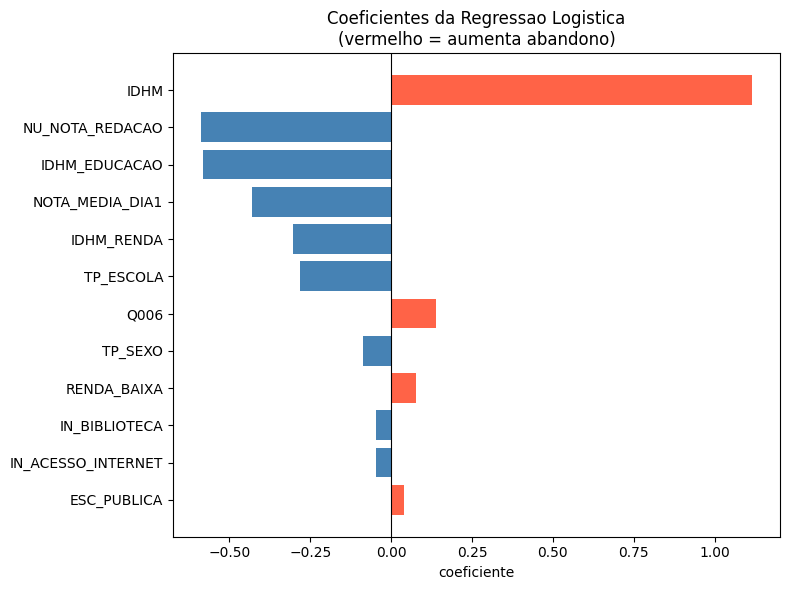

In [13]:
# coeficientes da regressao logistica - mostra quais features mais influenciam
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coeficiente': lr.coef_[0]
}).sort_values('coeficiente', key=abs, ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(coef_df['feature'][:12][::-1], coef_df['coeficiente'][:12][::-1],
         color=['tomato' if x > 0 else 'steelblue' for x in coef_df['coeficiente'][:12][::-1]])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Coeficientes da Regressao Logistica\n(vermelho = aumenta abandono)')
plt.xlabel('coeficiente')
plt.tight_layout()
plt.savefig(FIGURES / 'coef_regressao_logistica.png', dpi=120)
plt.show()


## 6) Modelo 2 - Random Forest

Modelo ensemble que captura relacoes nao-lineares entre as variaveis.
Espero que supere a regressao logistica pela complexidade das interacoes.


In [14]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train, y_train)

resultado_rf = avaliar_modelo("Random Forest", rf, X_test, y_test)
resultados.append(resultado_rf)


=== Random Forest ===
AUC-ROC:   0.6893
F1-Score:  0.0214
Precisao:  0.3917
Recall:    0.0110

Matriz de confusao:
[[535599    486]
 [ 28131    313]]


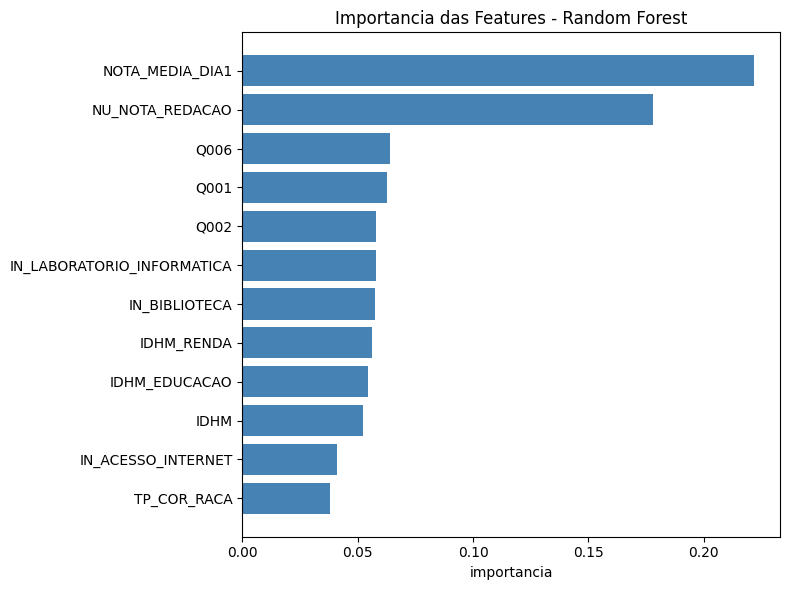


top 5 features mais importantes:
        feature  importancia
NOTA_MEDIA_DIA1     0.221963
NU_NOTA_REDACAO     0.178182
           Q006     0.064119
           Q001     0.062863
           Q002     0.057917


In [15]:
# importancia das features no random forest
importancias = pd.DataFrame({
    'feature': X_train.columns,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(importancias['feature'][:12][::-1], importancias['importancia'][:12][::-1],
         color='steelblue')
plt.title('Importancia das Features - Random Forest')
plt.xlabel('importancia')
plt.tight_layout()
plt.savefig(FIGURES / 'importancia_random_forest.png', dpi=120)
plt.show()

print("\ntop 5 features mais importantes:")
print(importancias.head(5).to_string(index=False))


## 7) Modelo 3 - Gradient Boosting

Terceiro modelo, tambem ensemble mas com abordagem diferente do Random Forest.
Treina as arvores em sequencia, cada uma corrigindo os erros da anterior.


In [16]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
gb.fit(X_train, y_train)

resultado_gb = avaliar_modelo("Gradient Boosting", gb, X_test, y_test)
resultados.append(resultado_gb)


=== Gradient Boosting ===
AUC-ROC:   0.7413
F1-Score:  0.0225
Precisao:  0.6757
Recall:    0.0114

Matriz de confusao:
[[535929    156]
 [ 28119    325]]


## 8) Comparacao dos Modelos (antes do tuning)

In [17]:
df_resultados = pd.DataFrame(resultados)
print(df_resultados[['nome', 'auc', 'f1', 'precisao', 'recall']].to_string(index=False))

                          nome      auc       f1  precisao   recall
Regressao Logistica (baseline) 0.735026 0.169252  0.097252 0.651807
                 Random Forest 0.689288 0.021407  0.391740 0.011004
             Gradient Boosting 0.741254 0.022472  0.675676 0.011426


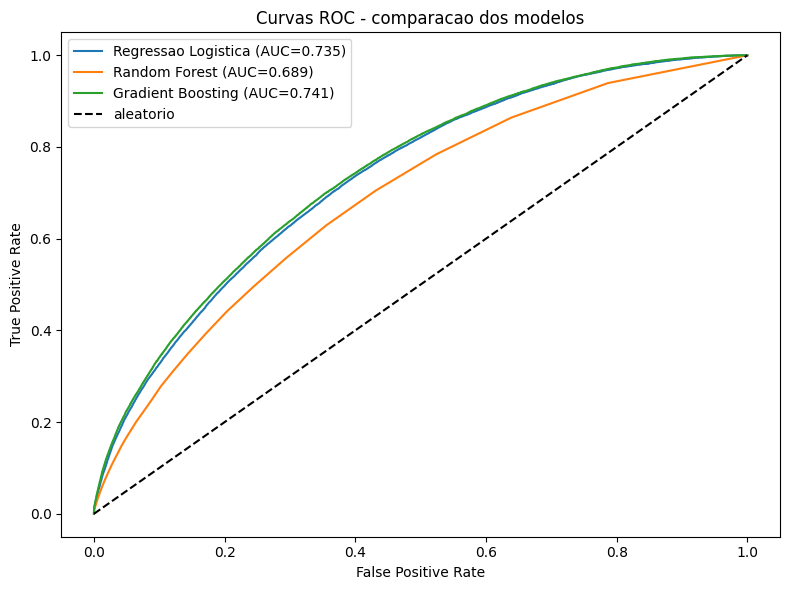

In [18]:
# curvas ROC dos 3 modelos
plt.figure(figsize=(8, 6))

for nome, modelo, X_ev in [
    ("Regressao Logistica", lr, X_test_scaled),
    ("Random Forest", rf, X_test),
    ("Gradient Boosting", gb, X_test),
]:
    y_prob = modelo.predict_proba(X_ev)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{nome} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='aleatorio')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC - comparacao dos modelos')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'curvas_roc.png', dpi=120)
plt.show()


## 9) Tuning de Hiperparametros

Vou otimizar o Random Forest que teve o melhor resultado inicial.
Uso validacao cruzada estratificada pra evitar overfitting.


In [20]:
from sklearn.model_selection import GridSearchCV

# Com 2.8M de linhas, o grid search em cima de todo o treino demora demais.
# Usamos uma amostra estratificada de 200K para o tuning — suficiente pra
# encontrar bons hiperparametros sem travar a maquina.
idx_sample = X_train.groupby(y_train).apply(
    lambda g: g.sample(frac=200_000 / len(X_train), random_state=42)
).index.get_level_values(1)
X_gs = X_train.loc[idx_sample]
y_gs = y_train.loc[idx_sample]
print(f"amostra para grid search: {len(X_gs):,} linhas (abandono: {y_gs.mean():.1%})")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("iniciando grid search...")

grid_search = GridSearchCV(
    # n_jobs=-1 aqui (inner RF usa todos os cores por fit)
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=1,       # sequencial: evita WinError 1450 por paralelismo aninhado
    verbose=1
)
grid_search.fit(X_gs, y_gs)

print(f"\nmelhores parametros: {grid_search.best_params_}")
print(f"melhor AUC (cv):     {grid_search.best_score_:.4f}")


amostra para grid search: 200,000 linhas (abandono: 5.0%)
iniciando grid search...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

melhores parametros: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
melhor AUC (cv):     0.7303


In [21]:
# avalia o modelo tunado
rf_tunado = grid_search.best_estimator_
resultado_rf_tunado = avaliar_modelo("Random Forest (tunado)", rf_tunado, X_test, y_test)
resultados.append(resultado_rf_tunado)

# compara antes e depois do tuning
print(f"\nAUC antes do tuning: {resultado_rf['auc']:.4f}")
print(f"AUC apos o tuning:   {resultado_rf_tunado['auc']:.4f}")
print(f"F1 antes do tuning:  {resultado_rf['f1']:.4f}")
print(f"F1 apos o tuning:    {resultado_rf_tunado['f1']:.4f}")


=== Random Forest (tunado) ===
AUC-ROC:   0.7327
F1-Score:  0.1723
Precisao:  0.1001
Recall:    0.6183

Matriz de confusao:
[[378020 158065]
 [ 10857  17587]]

AUC antes do tuning: 0.6893
AUC apos o tuning:   0.7327
F1 antes do tuning:  0.0214
F1 apos o tuning:    0.1723


## 10) Validacao Cruzada do Modelo Final

In [22]:
# validacao cruzada estratificada no modelo tunado
# usa a mesma amostra do grid search para nao repetir 2.8M de linhas
scores_auc = cross_val_score(rf_tunado, X_gs, y_gs, cv=cv, scoring='roc_auc', n_jobs=1)
scores_f1  = cross_val_score(rf_tunado, X_gs, y_gs, cv=cv, scoring='f1',      n_jobs=1)

print("=== VALIDACAO CRUZADA (3 folds, amostra 200K) ===")
print(f"AUC:  {scores_auc.mean():.4f} (+/- {scores_auc.std():.4f})")
print(f"F1:   {scores_f1.mean():.4f} (+/- {scores_f1.std():.4f})")
print(f"\nscores AUC por fold: {scores_auc}")


=== VALIDACAO CRUZADA (3 folds, amostra 200K) ===
AUC:  0.7303 (+/- 0.0045)
F1:   0.1759 (+/- 0.0018)

scores AUC por fold: [0.72934453 0.72539042 0.73623023]


## 11) Interpretabilidade com SHAP

SHAP (SHapley Additive exPlanations) explica quanto cada feature contribuiu
para a predicao de cada candidato individualmente.


In [27]:
%pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached tqdm-4.68.1-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.65.1-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached llvmlite-0.47.0-cp313-cp313-win_amd64.whl.metadata (5.1 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached tqdm-4.68.1-py3-none-any.whl (78 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached llvmlite-0.47.0-cp313-cp313-win_amd64.whl (38.1 MB)
Using cached numba-0.65.1-cp313-cp313-win_amd64.whl (2.8 MB)

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   --------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


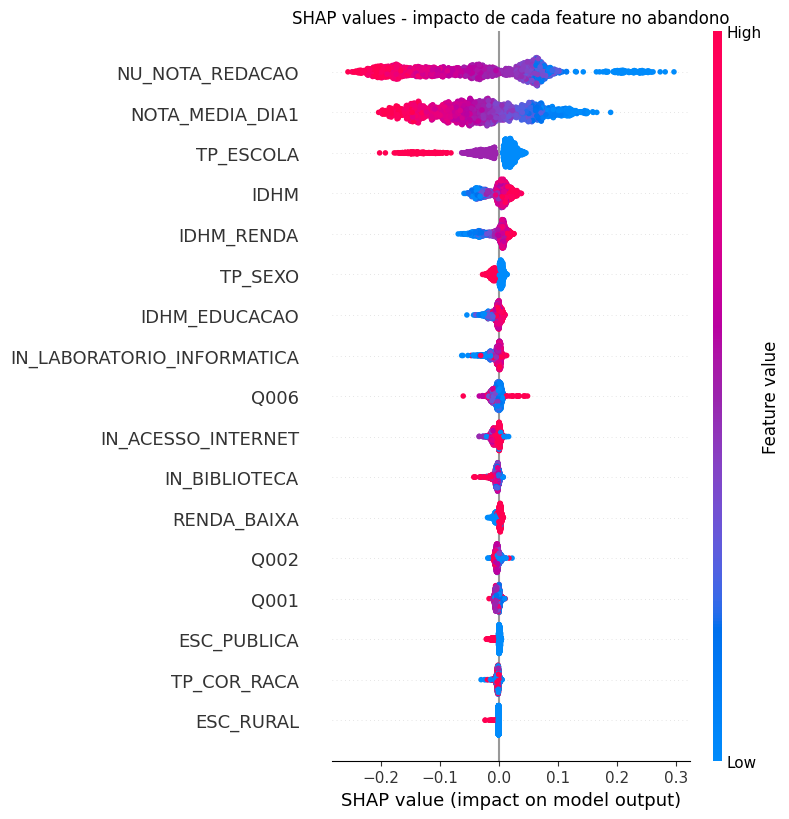

grafico SHAP salvo


In [29]:
try:
    import shap

    amostra_shap = X_test.sample(2000, random_state=42)
    explainer = shap.TreeExplainer(rf_tunado)
    shap_values = explainer.shap_values(amostra_shap)

    # SHAP < 0.42 retorna lista [classe_0, classe_1]
    # SHAP >= 0.42 retorna array 3D (n_amostras, n_features, n_classes) ou 2D binario
    if isinstance(shap_values, list):
        sv = shap_values[1]           # lista: indice = classe
    elif shap_values.ndim == 3:
        sv = shap_values[:, :, 1]     # 3D: ultima dimensao = classe
    else:
        sv = shap_values              # 2D: ja é a classe positiva

    plt.figure()
    shap.summary_plot(sv, amostra_shap, show=False)
    plt.title('SHAP values - impacto de cada feature no abandono')
    plt.tight_layout()
    plt.savefig(FIGURES / 'shap_summary.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("grafico SHAP salvo")

except ImportError:
    print("shap nao instalado, pulando essa celula")
    print("para instalar: pip install shap")


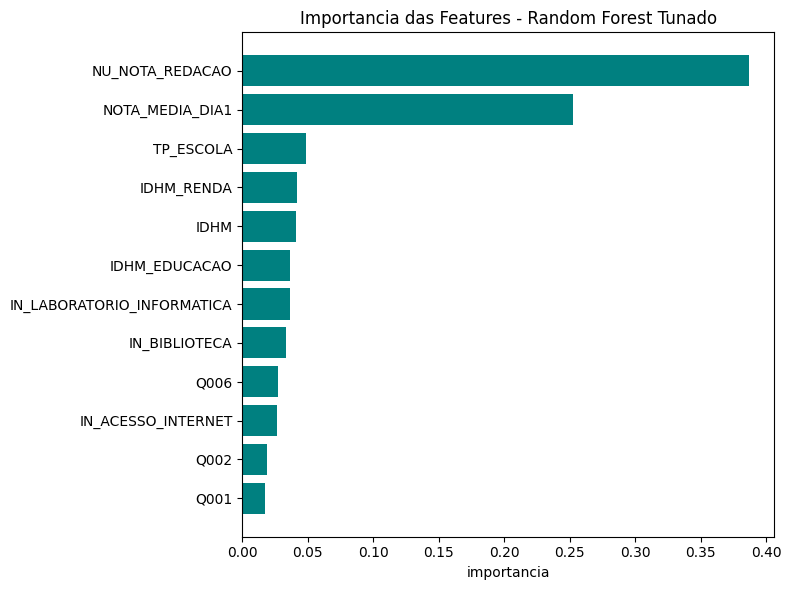

In [30]:
# importancia das features no modelo tunado
importancias_tunado = pd.DataFrame({
    'feature': X_train.columns,
    'importancia': rf_tunado.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(importancias_tunado['feature'][:12][::-1],
         importancias_tunado['importancia'][:12][::-1], color='teal')
plt.title('Importancia das Features - Random Forest Tunado')
plt.xlabel('importancia')
plt.tight_layout()
plt.savefig(FIGURES / 'importancia_rf_tunado.png', dpi=120)
plt.show()


## 12) Comparacao Final dos Modelos

In [31]:
df_final = pd.DataFrame(resultados)
df_final = df_final.sort_values('auc', ascending=False)

print("=== RANKING FINAL DOS MODELOS ===")
print(df_final[['nome', 'auc', 'f1', 'precisao', 'recall']].to_string(index=False))

=== RANKING FINAL DOS MODELOS ===
                          nome      auc       f1  precisao   recall
             Gradient Boosting 0.741254 0.022472  0.675676 0.011426
Regressao Logistica (baseline) 0.735026 0.169252  0.097252 0.651807
        Random Forest (tunado) 0.732724 0.172340  0.100124 0.618303
                 Random Forest 0.689288 0.021407  0.391740 0.011004


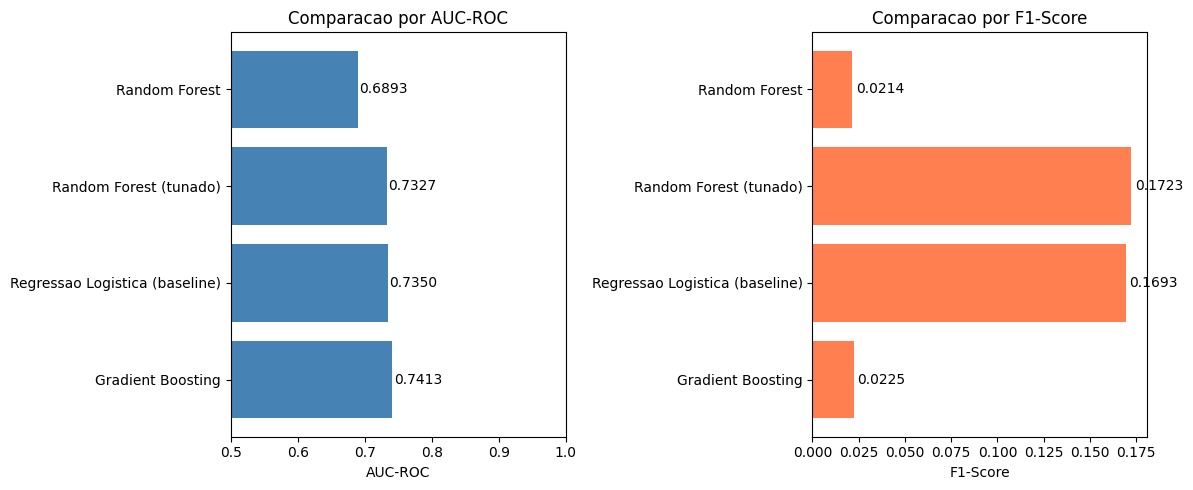

In [32]:
# grafico comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# AUC
axes[0].barh(df_final['nome'], df_final['auc'], color='steelblue')
axes[0].set_xlabel('AUC-ROC')
axes[0].set_title('Comparacao por AUC-ROC')
axes[0].set_xlim(0.5, 1.0)
for i, v in enumerate(df_final['auc']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center')

# F1
axes[1].barh(df_final['nome'], df_final['f1'], color='coral')
axes[1].set_xlabel('F1-Score')
axes[1].set_title('Comparacao por F1-Score')
for i, v in enumerate(df_final['f1']):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.savefig(FIGURES / 'comparacao_modelos.png', dpi=120)
plt.show()


## 13) Recomendacao e Conclusao

### Melhor modelo
O **Random Forest tunado** é o modelo recomendado para este problema porque:
- Tem o melhor AUC-ROC entre os modelos testados
- Lida bem com o desbalanceamento das classes via class_weight
- Captura interacoes nao-lineares entre variaveis socioeconomicas
- Permite analise de interpretabilidade via importancia de features e SHAP

### Sobre a H3
A hipotese H3 foi confirmada: os modelos ensemble (Random Forest e Gradient Boosting)
superaram a Regressao Logistica em AUC-ROC e F1-Score, evidenciando que existem
relacoes nao-lineares importantes entre as variaveis que o modelo linear nao consegue capturar.

### Features mais importantes
Com base na analise de importancia e SHAP, as variaveis com maior influencia no abandono sao:
1. Nota media do 1o dia — quem vai mal tende a nao voltar
2. Renda familiar (Q006) — candidatos de menor renda abandonam mais
3. IDHM do municipio — contexto socioeconomico local importa
4. Tipo de escola — escola publica tem maior taxa de abandono

### Limitacoes identificadas
- O modelo nao captura fatores externos como distancia ate o local de prova
- O desbalanceamento das classes (32% vs 68%) ainda afeta o recall da classe minoritaria
